# TrafficGuard · Adversarial Training Defence
**COMP47250 · Team Software Project · Project P14 · UCD Summer 2026**

**Owner:** Payal (Attack track) &nbsp;|&nbsp; **Contributor:** Soham (Model track)

---

### What this notebook does

Implements **Adversarial Training** — the gold-standard defence against pixel-level
evasion attacks (Madry et al., ICLR 2018).

Rather than cleaning the image before it reaches the model, adversarial training
**teaches the model to be robust directly** by retraining on adversarial examples.
The model learns that a perturbed "High" image is still "High" — no directional
class bias because the defence is baked into the weights, not applied as preprocessing.

---

### Why this fixes the class bias problem

Spatial smoothing and diffusion purification reduce high-frequency content —
which is also the signal the model uses to distinguish High congestion from Low.
This causes a systematic downward class bias.

Adversarial training has **no directional bias** because it operates on model weights.
The model sees perturbed examples of all three classes equally during training.

---

### Generation budget

| Attack | Images | Per class | Estimated time |
|---|---|---|---|
| FGSM | 15,000 | 5,000 each | ~3 min |
| PGD (40 steps) | 15,000 | 5,000 each | ~25 min |
| DeepFool (50 iter) | 6,000 | 2,000 each | ~50 min |
| **Total** | **36,000** | | **~78 min** |

---

### Saved outputs

| Path | Contents |
|---|---|
| `data/adversarial/fgsm/images.npy` | (15000, 3, 224, 224) float32 [0,1] |
| `data/adversarial/fgsm/labels.npy` | (15000,) int — true labels |
| `data/adversarial/pgd/images.npy` | (15000, 3, 224, 224) float32 [0,1] |
| `data/adversarial/pgd/labels.npy` | (15000,) int |
| `data/adversarial/deepfool/images.npy` | (6000, 3, 224, 224) float32 [0,1] |
| `data/adversarial/deepfool/labels.npy` | (6000,) int |
| `checkpoints/best_robust.pt` | Adversarially trained ResNet18 checkpoint |

---

### Notebook Structure

| # | Section |
|---|---|
| 0 | Setup & Imports |
| 1 | Configuration & Paths |
| 2 | Load Base Classifier |
| 3 | Balanced Sampling Helper |
| 4 | Generate FGSM Examples (15k, 5k per class) |
| 5 | Generate PGD Examples (15k, 5k per class) |
| 6 | Generate DeepFool Examples (6k, 2k per class) |
| 7 | Build Combined Dataset |
| 8 | Adversarial Training |
| 9 | Evaluate — Clean + Robust Accuracy |
| 10 | Summary |

---

### Reference
> Madry et al., *Towards Deep Learning Models Resistant to Adversarial Attacks.*
> ICLR 2018. https://arxiv.org/abs/1706.06083

---
## 0. Setup & Imports

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}' +
      (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))
print('All imports OK.')

PyTorch  : 2.11.0+cu128
Device   : cuda (NVIDIA GeForce RTX 5050 Laptop GPU)
All imports OK.


---
## 1. Configuration & Paths

All paths, counts and hyperparameters in one place.
**Only edit this cell.**

> **Cross-machine note:** all paths are relative to the repo root so they
> work on any team member's machine without changes.

In [16]:
# ── Paths ─────────────────────────────────────────────────────────────────────
CHECKPOINT_PATH  = Path(r"C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\model\checkpoints\best.pt")
ROBUST_CKPT_PATH = Path(r"C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\defences\checkpoints\best_robust.pt")
MANIFEST_PATH    = Path(r"C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\pipeline_output\labelled_manifest.csv")
IMAGES_DIR       = Path(r"C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\train")

# Adversarial data output — organised by attack inside data/adversarial/
ADV_ROOT = Path(r"C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\adversarial")
ADV_DIRS = {
    'fgsm':     ADV_ROOT / 'fgsm',
    'pgd':      ADV_ROOT / 'pgd',
    'deepfool': ADV_ROOT / 'deepfool',
}
for d in ADV_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ── Class mapping — must match Soham's training notebook exactly ──────────────
CLASS_NAMES  = ['Low', 'Medium', 'High']
LABEL_MAP    = {'Low': 0, 'Medium': 1, 'High': 2}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES  = 3

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Per-attack generation counts (balanced across 3 classes) ──────────────────
# Each attack uses its own count — split evenly across Low / Medium / High.
# Total generation time target: ~78 minutes on RTX 5050.
FGSM_COUNT     = 15000   # 5000 per class  — ~3 min
PGD_COUNT      = 15000   # 5000 per class  — ~25 min
DEEPFOOL_COUNT = 6000    #  2000 per class  — ~50 min

# ── Attack hyperparameters ────────────────────────────────────────────────────
FGSM_EPS      = 0.10
PGD_EPS       = 0.10
PGD_STEPS     = 40
PGD_ALPHA     = PGD_EPS / 10
DEEPFOOL_ITER = 50
DEEPFOOL_OVER = 0.02

# ── Adversarial training hyperparameters ──────────────────────────────────────
ADV_EPOCHS = 15     # fine-tuning from best.pt — fewer epochs than clean training
ADV_BATCH  = 64
ADV_LR     = 5e-5   # lower than clean training LR — preserves clean accuracy
ADV_SEED   = 42

# ── Generation batch size ────────────────────────────────────────────────────
GEN_BATCH = 32

torch.manual_seed(ADV_SEED)
np.random.seed(ADV_SEED)

print(f'Checkpoint       : {CHECKPOINT_PATH}  exists={CHECKPOINT_PATH.exists()}')
print(f'Manifest         : {MANIFEST_PATH}  exists={MANIFEST_PATH.exists()}')
print(f'ADV output root  : {ADV_ROOT}')
print()
print('Generation counts (per attack, balanced across 3 classes):')
print(f'  FGSM     : {FGSM_COUNT:>6,}  ({FGSM_COUNT//NUM_CLASSES:,} per class)')
print(f'  PGD      : {PGD_COUNT:>6,}  ({PGD_COUNT//NUM_CLASSES:,} per class)')
print(f'  DeepFool : {DEEPFOOL_COUNT:>6,}  ({DEEPFOOL_COUNT//NUM_CLASSES:,} per class)')
print(f'  Total    : {FGSM_COUNT+PGD_COUNT+DEEPFOOL_COUNT:>6,}')
print()
print('Adversarial training:')
print(f'  Epochs   : {ADV_EPOCHS}')
print(f'  Batch    : {ADV_BATCH}')
print(f'  LR       : {ADV_LR}')

Checkpoint       : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\model\checkpoints\best.pt  exists=True
Manifest         : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\pipeline_output\labelled_manifest.csv  exists=True
ADV output root  : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\adversarial

Generation counts (per attack, balanced across 3 classes):
  FGSM     : 15,000  (5,000 per class)
  PGD      : 15,000  (5,000 per class)
  DeepFool :  6,000  (2,000 per class)
  Total    : 36,000

Adversarial training:
  Epochs   : 15
  Batch    : 64
  LR       : 5e-05


---
## 2. Load Base Classifier

The base classifier is Soham's trained ResNet18 from `best.pt`.
This is:
1. The model we **attack** to generate adversarial examples
2. The **starting point** for adversarial training — we fine-tune from these
   weights rather than training from scratch, which preserves clean accuracy

In [3]:
class NormalizedResNet(nn.Module):
    """
    ResNet18 with ImageNet normalisation applied internally.
    Accepts raw [0,1] pixel tensors — normalisation happens in forward().
    Must match the architecture in ml.py exactly for checkpoint compatibility.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(backbone.fc.in_features, num_classes),
        )
        self.backbone = backbone
        self.register_buffer(
            'mean', torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
        )
        self.register_buffer(
            'std', torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
        )

    def forward(self, x_pixels):
        return self.backbone((x_pixels - self.mean) / self.std)


def load_checkpoint(path, device):
    """
    Load a NormalizedResNet checkpoint.
    Returns model in eval() mode.
    Supports both plain state_dict and full checkpoint dict formats.
    """
    if not Path(path).exists():
        raise FileNotFoundError(
            f'Checkpoint not found: {path}\n'
            f'Make sure Soham has committed checkpoints/best.pt to the repo.'
        )
    model = NormalizedResNet().to(device)
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt)
    try:
        model.load_state_dict(state)
    except RuntimeError:
        # Fallback if checkpoint was saved from a non-wrapped ResNet18
        model.backbone.load_state_dict(state)

    epoch   = ckpt.get('epoch', '?')
    val_acc = ckpt.get('val_acc', None)
    print(f'Loaded  : epoch {epoch}' +
          (f', val_acc={val_acc:.2%}' if val_acc else ''))
    model.eval()
    return model


base_model = load_checkpoint(CHECKPOINT_PATH, DEVICE)
print(f'Device  : {DEVICE}')

# ToTensor only — NormalizedResNet handles normalisation internally
_TO_PIXELS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
print('Base classifier ready.')

Loaded  : epoch 17, val_acc=87.14%
Device  : cuda
Base classifier ready.


---
## 3. Dataset Class & Balanced Sampling Helper

Each attack generates examples from a **balanced** sample of training images —
equal numbers of Low, Medium and High images per attack type.

Why balance matters here: if the generation set is skewed (e.g. more Medium
than High), the adversarially-trained model will see more adversarial Medium
examples than High examples, which can introduce a new robustness bias —
exactly the opposite of what we're trying to fix.

In [4]:
class MIOTCDDataset(Dataset):
    """
    Reads labelled_manifest.csv from Walid's pipeline.
    Returns (pixel_tensor [0,1], label_int, image_path_str).
    """
    def __init__(self, manifest_path, split, images_dir=None, transform=None):
        df = pd.read_csv(manifest_path, dtype={'image_id': str})
        self.df         = df[df['split'] == split].reset_index(drop=True)
        self.images_dir = Path(images_dir) if images_dir else None
        self.transform  = transform or _TO_PIXELS
        self.df         = self.df.copy()
        self.df['label_idx'] = self.df['congestion_label'].map(LABEL_MAP)

    def __len__(self):
        return len(self.df)

    def _path(self, row):
        if self.images_dir:
            return self.images_dir / f"{row['image_id']}.jpg"
        return Path(row['image_path'])

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(self._path(row)).convert('RGB')
        label = int(row['label_idx'])
        return self.transform(image), label, str(self._path(row))


def sample_balanced(manifest_path, split, images_dir, n_per_class, seed=ADV_SEED):
    """
    Return a MIOTCDDataset subset with exactly n_per_class images from each
    of the three congestion classes.

    Args:
        manifest_path : path to labelled_manifest.csv
        split         : 'train' | 'val' | 'test'
        images_dir    : path to MIO-TCD train/ folder
        n_per_class   : how many images per class (Low / Medium / High)
        seed          : random seed for reproducibility

    Returns:
        MIOTCDDataset with balanced df of size 3 * n_per_class
    """
    ds      = MIOTCDDataset(manifest_path, split, images_dir)
    sampled = []
    for cls_idx in range(NUM_CLASSES):
        cls_rows = ds.df[ds.df['label_idx'] == cls_idx]
        n        = min(n_per_class, len(cls_rows))
        sampled.append(cls_rows.sample(n, random_state=seed))
        if n < n_per_class:
            print(f'  ⚠ {CLASS_NAMES[cls_idx]}: only {n} available, wanted {n_per_class}')

    ds.df = pd.concat(sampled).sample(frac=1, random_state=seed).reset_index(drop=True)
    total = len(ds.df)
    print(f'Balanced sample ({split}): {total} images')
    for c in CLASS_NAMES:
        n = (ds.df['congestion_label'] == c).sum()
        print(f'  {c:<8}: {n:,}')
    return ds


print('MIOTCDDataset and sample_balanced() defined.')

MIOTCDDataset and sample_balanced() defined.


In [5]:
# ── Build one balanced generation dataset per attack ──────────────────────────
print('FGSM generation set:')
fgsm_gen_ds = sample_balanced(
    MANIFEST_PATH, 'train', IMAGES_DIR, FGSM_COUNT // NUM_CLASSES
)
print()

print('PGD generation set:')
pgd_gen_ds = sample_balanced(
    MANIFEST_PATH, 'train', IMAGES_DIR, PGD_COUNT // NUM_CLASSES
)
print()

print('DeepFool generation set:')
deepfool_gen_ds = sample_balanced(
    MANIFEST_PATH, 'train', IMAGES_DIR, DEEPFOOL_COUNT // NUM_CLASSES
)

fgsm_gen_loader     = DataLoader(fgsm_gen_ds,     batch_size=GEN_BATCH, shuffle=False, num_workers=0)
pgd_gen_loader      = DataLoader(pgd_gen_ds,      batch_size=GEN_BATCH, shuffle=False, num_workers=0)
deepfool_gen_loader = DataLoader(deepfool_gen_ds, batch_size=GEN_BATCH, shuffle=False, num_workers=0)

print()
print(f'FGSM loader     : {len(fgsm_gen_loader)} batches  ({FGSM_COUNT:,} images, {FGSM_COUNT//NUM_CLASSES:,}/class)')
print(f'PGD loader      : {len(pgd_gen_loader)} batches  ({PGD_COUNT:,} images, {PGD_COUNT//NUM_CLASSES:,}/class)')
print(f'DeepFool loader : {len(deepfool_gen_loader)} batches  ({DEEPFOOL_COUNT:,} images, {DEEPFOOL_COUNT//NUM_CLASSES:,}/class)')

FGSM generation set:
Balanced sample (train): 15000 images
  Low     : 5,000
  Medium  : 5,000
  High    : 5,000

PGD generation set:
Balanced sample (train): 15000 images
  Low     : 5,000
  Medium  : 5,000
  High    : 5,000

DeepFool generation set:
Balanced sample (train): 6000 images
  Low     : 2,000
  Medium  : 2,000
  High    : 2,000

FGSM loader     : 469 batches  (15,000 images, 5,000/class)
PGD loader      : 469 batches  (15,000 images, 5,000/class)
DeepFool loader : 188 batches  (6,000 images, 2,000/class)


---
## 3.1 Generation Helpers

Reusable functions for saving, loading and checking adversarial `.npy` files.

**Re-run safety:** each generation section checks if `.npy` files already
exist before running. If yes, it skips generation entirely — so you can
re-run the notebook without regenerating from scratch.

In [6]:
def save_adv(attack_name, images_np, labels_np):
    """Save adversarial arrays to data/adversarial/<attack_name>/."""
    out_dir = ADV_DIRS[attack_name]
    np.save(out_dir / 'images.npy', images_np.astype(np.float32))
    np.save(out_dir / 'labels.npy', labels_np)
    print(f'Saved to {out_dir}/')
    print(f'  images.npy : {images_np.shape}  dtype={images_np.dtype}')
    print(f'  labels.npy : {labels_np.shape}')
    # Print class distribution of saved data
    for i, c in enumerate(CLASS_NAMES):
        print(f'  {c:<8}: {(labels_np == i).sum():,}')


def load_adv(attack_name):
    """Load pre-generated adversarial arrays from disk."""
    out_dir = ADV_DIRS[attack_name]
    images  = np.load(out_dir / 'images.npy')
    labels  = np.load(out_dir / 'labels.npy')
    print(f'Loaded {attack_name}: {images.shape} images, {labels.shape} labels')
    return images, labels


def already_generated(attack_name):
    """True if both .npy files already exist — skip regeneration."""
    d = ADV_DIRS[attack_name]
    return (d / 'images.npy').exists() and (d / 'labels.npy').exists()


def quick_asr_check(attack_name, n=200):
    """
    Quick attack success rate check on first n saved examples.
    ASR = fraction where the base model prediction changed from the true label.
    """
    images, labels = load_adv(attack_name)
    x = torch.tensor(images[:n]).to(DEVICE)
    y = torch.tensor(labels[:n]).to(DEVICE)
    with torch.no_grad():
        preds = base_model(x).argmax(dim=1)
    asr = (preds != y).float().mean().item()
    print(f'ASR on first {n} {attack_name} examples: {asr:.1%}')
    # Per class breakdown
    for i, c in enumerate(CLASS_NAMES):
        mask = y == i
        if mask.sum() > 0:
            cls_asr = (preds[mask] != y[mask]).float().mean().item()
            print(f'  {c:<8}: {cls_asr:.1%}')


print('Generation helpers defined.')

Generation helpers defined.


---
## 4. Generate FGSM Adversarial Examples

**15,000 images — 5,000 per class — estimated ~3 minutes**

FGSM: one-step gradient sign method.
```
x_adv = clip(x + ε · sign(∇_x L(f(x), y)), 0, 1)
```

Fastest of the three attacks — single forward + backward pass per image.

In [7]:
if already_generated('fgsm'):
    print('✓ FGSM .npy files already exist — skipping generation.')
    quick_asr_check('fgsm')
else:
    print(f'Generating {FGSM_COUNT:,} FGSM examples (ε={FGSM_EPS})...')
    print(f'  Saving batch-by-batch to avoid memory accumulation.')

    out_dir = ADV_DIRS['fgsm']
    img_path = out_dir / 'images.npy'
    lbl_path = out_dir / 'labels.npy'

    # Pre-allocate memory-mapped .npy files on disk
    # This writes directly to disk per batch — never holds full dataset in RAM
    img_mmap = np.lib.format.open_memmap(
        img_path, mode='w+', dtype=np.float32,
        shape=(FGSM_COUNT, 3, 224, 224)
    )
    lbl_mmap = np.lib.format.open_memmap(
        lbl_path, mode='w+', dtype=np.int64,
        shape=(FGSM_COUNT,)
    )

    idx = 0
    t0  = time.time()

    for x_batch, y_batch, _ in tqdm(fgsm_gen_loader, desc='FGSM'):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_batch.requires_grad_(True)
        loss = F.cross_entropy(base_model(x_batch), y_batch)
        base_model.zero_grad()
        loss.backward()

        with torch.no_grad():
            x_adv = (x_batch + FGSM_EPS * x_batch.grad.sign()).clamp(0, 1)

        n = x_adv.shape[0]
        img_mmap[idx:idx+n] = x_adv.detach().cpu().numpy()
        lbl_mmap[idx:idx+n] = y_batch.cpu().numpy()
        idx += n

    img_mmap.flush()
    lbl_mmap.flush()
    del img_mmap, lbl_mmap

    elapsed = time.time() - t0
    print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)')
    print(f'Saved to {out_dir}/')
    print(f'  images.npy : ({FGSM_COUNT}, 3, 224, 224)  float32')
    print(f'  labels.npy : ({FGSM_COUNT},)  int64')
    print()
    quick_asr_check('fgsm')

✓ FGSM .npy files already exist — skipping generation.
Loaded fgsm: (15000, 3, 224, 224) images, (15000,) labels
ASR on first 200 fgsm examples: 79.5%
  Low     : 57.3%
  Medium  : 85.5%
  High    : 100.0%


---
## 5. Generate PGD Adversarial Examples

**15,000 images — 5,000 per class — estimated ~25 minutes**

PGD: iterative FGSM with projection back into the L∞ epsilon ball.
```
x₀    = x  (start from the clean image)
xₜ₊₁ = clip(xₜ + α · sign(∇_x L(f(xₜ), y)), x-ε, x+ε)
```

Stronger than FGSM because it takes 40 smaller steps instead of one large one,
finding a better adversarial direction in the loss landscape.

In [8]:
if already_generated('pgd'):
    print('✓ PGD .npy files already exist — skipping generation.')
    quick_asr_check('pgd')
else:
    print(f'Generating {PGD_COUNT:,} PGD examples '
          f'(ε={PGD_EPS}, steps={PGD_STEPS}, α={PGD_ALPHA:.4f})...')
    print(f'  Saving batch-by-batch to avoid memory accumulation.')

    out_dir  = ADV_DIRS['pgd']
    img_mmap = np.lib.format.open_memmap(
        out_dir / 'images.npy', mode='w+', dtype=np.float32,
        shape=(PGD_COUNT, 3, 224, 224)
    )
    lbl_mmap = np.lib.format.open_memmap(
        out_dir / 'labels.npy', mode='w+', dtype=np.int64,
        shape=(PGD_COUNT,)
    )

    idx = 0
    t0  = time.time()

    for x_clean, y_batch, _ in tqdm(pgd_gen_loader, desc='PGD'):
        x_clean = x_clean.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_adv = x_clean.clone().detach()
        for step in range(PGD_STEPS):
            x_adv.requires_grad_(True)
            loss = F.cross_entropy(base_model(x_adv), y_batch)
            base_model.zero_grad()
            loss.backward()
            with torch.no_grad():
                x_adv  = x_adv + PGD_ALPHA * x_adv.grad.sign()
                delta  = (x_adv - x_clean).clamp(-PGD_EPS, PGD_EPS)
                x_adv  = (x_clean + delta).clamp(0, 1).detach()

        n = x_adv.shape[0]
        img_mmap[idx:idx+n] = x_adv.cpu().numpy()
        lbl_mmap[idx:idx+n] = y_batch.cpu().numpy()
        idx += n

    img_mmap.flush()
    lbl_mmap.flush()
    del img_mmap, lbl_mmap

    elapsed = time.time() - t0
    print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)')
    print(f'Saved to {out_dir}/')
    print(f'  images.npy : ({PGD_COUNT}, 3, 224, 224)  float32')
    print(f'  labels.npy : ({PGD_COUNT},)  int64')
    print()
    quick_asr_check('pgd')

✓ PGD .npy files already exist — skipping generation.
Loaded pgd: (15000, 3, 224, 224) images, (15000,) labels
ASR on first 200 pgd examples: 100.0%
  Low     : 100.0%
  Medium  : 100.0%
  High    : 100.0%


---
## 6. Generate DeepFool Adversarial Examples

**6,000 images — 2,000 per class — estimated ~50 minutes**

DeepFool finds the **minimum-norm perturbation** to cross the nearest
decision boundary — strictly more efficient than FGSM/PGD in terms of
perturbation size needed to fool the model.

It works by linearising the classifier around x and computing the
shortest vector to the nearest class boundary, then stepping across it.

This is the slowest generation step — processed one image at a time
because the iterative boundary-finding is inherently sequential.

In [9]:
def deepfool_single(x_single, model, max_iter=DEEPFOOL_ITER, overshoot=DEEPFOOL_OVER):
    """
    Run DeepFool on a single image tensor (1, 3, H, W) in [0,1].

    Returns the adversarial image tensor (1, 3, H, W) in [0,1].

    Algorithm (Moosavi-Dezfooli et al. 2016):
      At each step, linearise f around the current x and find the class
      boundary closest in L2 distance. Step across that boundary and repeat
      until the prediction changes (or max_iter is reached).
    """
    x_orig = x_single.clone().detach()
    x      = x_single.clone().detach()
    r_total = torch.zeros_like(x)

    orig_label = int(model(x).argmax())
    cur_label  = orig_label
    step       = 0

    while cur_label == orig_label and step < max_iter:
        x.requires_grad_(True)
        fs = model(x)[0]   # (num_classes,)
        grads = []

        for k in range(NUM_CLASSES):
            model.zero_grad()
            if x.grad is not None:
                x.grad.zero_()
            fs[k].backward(retain_graph=(k < NUM_CLASSES - 1))
            grads.append(x.grad.detach().clone())

        # Find the class boundary that requires the smallest perturbation
        g_orig = grads[orig_label]
        best_dist, best_w, best_f = None, None, None

        for k in range(NUM_CLASSES):
            if k == orig_label:
                continue
            w_k = grads[k] - g_orig
            f_k = (fs[k] - fs[orig_label]).detach()
            dist = abs(float(f_k)) / (w_k.flatten().norm().item() + 1e-8)
            if best_dist is None or dist < best_dist:
                best_dist, best_w, best_f = dist, w_k, f_k

        # Step across the nearest boundary
        r_i = ((abs(float(best_f)) + 1e-4) * best_w /
                (best_w.flatten().norm().item() ** 2 + 1e-8))
        r_total = r_total + r_i

        x = (x_orig + (1 + overshoot) * r_total).clamp(0, 1).detach()
        with torch.no_grad():
            cur_label = int(model(x).argmax())
        step += 1

    return x.detach()


print('deepfool_single() defined.')

deepfool_single() defined.


In [10]:
if already_generated('deepfool'):
    print('✓ DeepFool .npy files already exist — skipping generation.')
    quick_asr_check('deepfool')
else:
    print(f'Generating {DEEPFOOL_COUNT:,} DeepFool examples...')
    print(f'  2,000 Low  |  2,000 Medium  |  2,000 High')
    print(f'  Saving batch-by-batch to avoid memory accumulation.')
    print(f'  Estimated: ~50 min on GPU. Progress logged every 200 images.')

    out_dir  = ADV_DIRS['deepfool']
    img_mmap = np.lib.format.open_memmap(
        out_dir / 'images.npy', mode='w+', dtype=np.float32,
        shape=(DEEPFOOL_COUNT, 3, 224, 224)
    )
    lbl_mmap = np.lib.format.open_memmap(
        out_dir / 'labels.npy', mode='w+', dtype=np.int64,
        shape=(DEEPFOOL_COUNT,)
    )

    idx    = 0
    t0     = time.time()
    n_done = 0

    for x_clean_batch, y_batch, _ in tqdm(deepfool_gen_loader, desc='DeepFool'):
        x_clean_batch = x_clean_batch.to(DEVICE)
        adv_batch     = []

        for i in range(x_clean_batch.shape[0]):
            x_adv_i = deepfool_single(x_clean_batch[i:i+1], base_model)
            adv_batch.append(x_adv_i.cpu())

        x_adv_batch = torch.cat(adv_batch, dim=0)
        n = x_adv_batch.shape[0]
        img_mmap[idx:idx+n] = x_adv_batch.numpy()
        lbl_mmap[idx:idx+n] = y_batch.numpy()
        idx    += n
        n_done += n

        if n_done % 200 == 0:
            elapsed = time.time() - t0
            eta     = elapsed / n_done * (DEEPFOOL_COUNT - n_done)
            print(f'  {n_done:>5}/{DEEPFOOL_COUNT}  |  '
                  f'elapsed {elapsed/60:.1f} min  |  '
                  f'ETA {eta/60:.1f} min')

    img_mmap.flush()
    lbl_mmap.flush()
    del img_mmap, lbl_mmap

    elapsed = time.time() - t0
    print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)')
    print(f'Saved to {out_dir}/')
    print(f'  images.npy : ({DEEPFOOL_COUNT}, 3, 224, 224)  float32')
    print(f'  labels.npy : ({DEEPFOOL_COUNT},)  int64')
    print()
    quick_asr_check('deepfool')

✓ DeepFool .npy files already exist — skipping generation.
Loaded deepfool: (6000, 3, 224, 224) images, (6000,) labels
ASR on first 200 deepfool examples: 82.0%
  Low     : 86.8%
  Medium  : 77.5%
  High    : 81.1%


---
## 7. Build Combined Dataset

Combine clean training images with all three adversarial sets.

```
Clean train (~77k)  +  FGSM (15k)  +  PGD (15k)  +  DeepFool (6k)  =  ~113k
```

The clean images deliberately dominate (~68% of the combined set).
This is the standard adversarial training ratio from the literature —
too high an adversarial ratio causes clean accuracy to drop noticeably.

In [11]:
class AdversarialNpyDataset(Dataset):
    """
    Loads pre-generated adversarial .npy files.
    Returns (pixel_tensor [0,1], label_int).
    Light augmentation (horizontal flip only) — colour jitter would
    wash out the adversarial perturbation so it is intentionally omitted.
    """
    def __init__(self, attack_name, augment=True):
        self.images    = np.load(ADV_DIRS[attack_name] / 'images.npy')
        self.labels    = np.load(ADV_DIRS[attack_name] / 'labels.npy')
        self.transform = transforms.RandomHorizontalFlip(p=0.5) if augment else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx], dtype=torch.float32)
        if self.transform:
            x = self.transform(x)
        return x, int(self.labels[idx])


class DropPath(Dataset):
    """Wrapper that drops the path string from MIOTCDDataset's return tuple."""
    def __init__(self, ds):
        self.ds = ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        x, y, *_ = self.ds[i]
        return x, y


# Clean training set — same augmentation as Soham's training notebook
clean_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.05),
    transforms.RandomRotation(degrees=5),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
])

clean_train_ds = MIOTCDDataset(
    MANIFEST_PATH, 'train', IMAGES_DIR, transform=clean_transform
)

# Adversarial datasets from disk
fgsm_ds     = AdversarialNpyDataset('fgsm')
pgd_ds      = AdversarialNpyDataset('pgd')
deepfool_ds = AdversarialNpyDataset('deepfool')

# Combined
combined_ds = ConcatDataset([
    DropPath(clean_train_ds),
    fgsm_ds,
    pgd_ds,
    deepfool_ds,
])

# Val and test — clean images, no augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
val_ds  = MIOTCDDataset(MANIFEST_PATH, 'val',  IMAGES_DIR, transform=val_transform)
test_ds = MIOTCDDataset(MANIFEST_PATH, 'test', IMAGES_DIR, transform=val_transform)

print('Combined training set composition:')
print(f'  Clean      : {len(clean_train_ds):>7,}  ({len(clean_train_ds)/len(combined_ds)*100:.0f}%)')
print(f'  FGSM adv   : {len(fgsm_ds):>7,}  ({len(fgsm_ds)/len(combined_ds)*100:.0f}%)')
print(f'  PGD adv    : {len(pgd_ds):>7,}  ({len(pgd_ds)/len(combined_ds)*100:.0f}%)')
print(f'  DeepFool   : {len(deepfool_ds):>7,}  ({len(deepfool_ds)/len(combined_ds)*100:.0f}%)')
print(f'  ─────────────────────────────')
print(f'  Total      : {len(combined_ds):>7,}')
print(f'  Val        : {len(val_ds):>7,}')
print(f'  Test       : {len(test_ds):>7,}')

Combined training set composition:
  Clean      :  76,990  (68%)
  FGSM adv   :  15,000  (13%)
  PGD adv    :  15,000  (13%)
  DeepFool   :   6,000  (5%)
  ─────────────────────────────
  Total      : 112,990
  Val        :  16,499
  Test       :  16,499


In [13]:
train_loader_adv = DataLoader(
    combined_ds, batch_size=ADV_BATCH,
    shuffle=True, num_workers=0, drop_last=True,
)
val_loader_adv = DataLoader(
    DropPath(val_ds), batch_size=ADV_BATCH,
    shuffle=False, num_workers=0,
)
test_loader_adv = DataLoader(
    DropPath(test_ds), batch_size=ADV_BATCH,
    shuffle=False, num_workers=0,
)

print(f'Train batches : {len(train_loader_adv):,}')
print(f'Val batches   : {len(val_loader_adv):,}')
print(f'Test batches  : {len(test_loader_adv):,}')

Train batches : 1,765
Val batches   : 258
Test batches  : 258


---
## 8. Adversarial Training

Fine-tune from `best.pt` on the combined clean + adversarial dataset.

### Key decisions

**Start from best.pt, not random weights.** The model already knows how to
classify congestion. Adversarial training teaches it to be robust — not to
learn from scratch. Starting from a trained checkpoint dramatically reduces
the number of epochs needed and preserves clean accuracy.

**Lower learning rate (5e-5 vs 1e-4).** Fine-tuning an already-capable model.
Large gradient steps would destroy the clean accuracy the base model already has.

**Fewer epochs (15 vs 25).** The model converges faster from a strong init.
Early stopping saves the best val-accuracy checkpoint automatically.

In [14]:
# Load a fresh copy of best.pt to fine-tune
# Important: use a separate variable, not base_model — we keep the original
# unmodified for the comparison in Section 9.
robust_model = load_checkpoint(CHECKPOINT_PATH, DEVICE)
robust_model.train()

optimizer = torch.optim.AdamW(
    robust_model.parameters(), lr=ADV_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=ADV_EPOCHS, eta_min=1e-6
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f'Fine-tuning from best.pt')
print(f'  Epochs     : {ADV_EPOCHS}')
print(f'  Batch size : {ADV_BATCH}')
print(f'  LR         : {ADV_LR}')
print(f'  Loss       : CrossEntropyLoss(label_smoothing=0.1)')
print(f'  Scheduler  : CosineAnnealingLR')

Loaded  : epoch 17, val_acc=87.14%
Fine-tuning from best.pt
  Epochs     : 15
  Batch size : 64
  LR         : 5e-05
  Loss       : CrossEntropyLoss(label_smoothing=0.1)
  Scheduler  : CosineAnnealingLR


In [17]:
def evaluate_model(model, loader):
    """Evaluate model on a dataloader. Returns (accuracy, preds, labels)."""
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            preds  = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return correct / total, all_preds, all_labels


best_val_acc = 0.0
log_rows     = []

header = (f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  "
          f"{'Val Acc':>8}  {'LR':>9}  {'Time':>7}")
print(header)
print('─' * len(header))

for epoch in range(1, ADV_EPOCHS + 1):
    robust_model.train()
    t0 = time.time()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(train_loader_adv,
                     desc=f'Epoch {epoch}/{ADV_EPOCHS}', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(robust_model(x), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds   = robust_model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    scheduler.step()
    train_loss = running_loss / total
    train_acc  = correct / total
    val_acc, _, _ = evaluate_model(robust_model, val_loader_adv)
    elapsed    = time.time() - t0
    lr         = scheduler.get_last_lr()[0]

    log_rows.append([epoch, train_loss, train_acc, val_acc, lr])

    saved = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                'epoch':            epoch,
                'model_state_dict': robust_model.state_dict(),
                'val_acc':          val_acc,
                'class_names':      CLASS_NAMES,
                'training_type':    'adversarial',
                'attacks_trained':  ['fgsm', 'pgd', 'deepfool'],
                'fgsm_eps':         FGSM_EPS,
                'pgd_eps':          PGD_EPS,
                'pgd_steps':        PGD_STEPS,
            },
            ROBUST_CKPT_PATH,
        )
        saved = '  ← best saved ✓'

    print(
        f"{epoch:>6}  {train_loss:>10.4f}  {train_acc:>8.2%}  "
        f"{val_acc:>7.2%}  {lr:>9.2e}  {elapsed:>6.1f}s" + saved
    )

print(f'\nTraining complete.')
print(f'Best val accuracy : {best_val_acc:.2%}')
print(f'Saved             : {ROBUST_CKPT_PATH}')

 Epoch  Train Loss  Train Acc   Val Acc         LR     Time
───────────────────────────────────────────────────────────


Epoch 1/15:   0%|          | 0/1765 [00:00<?, ?it/s]

     1      0.4607    91.81%   87.39%   4.79e-05  1643.9s  ← best saved ✓


Epoch 2/15:   0%|          | 0/1765 [00:00<?, ?it/s]

     2      0.4501    92.31%   86.88%   4.53e-05  1567.3s


...

    13      0.4004    94.19%   87.12%   1.54e-06  1567.8s


Epoch 14/15:   0%|          | 0/1765 [00:00<?, ?it/s]

    14      0.3983    94.24%   87.57%   1.00e-06  1525.7s  ← best saved ✓


Epoch 15/15:   0%|          | 0/1765 [00:00<?, ?it/s]

    15      0.3992    94.23%   87.59%   1.54e-06  1534.3s  ← best saved ✓

Training complete.
Best val accuracy : 87.59%
Saved             : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\defences\checkpoints\best_robust.pt


### 8.1 Training Curves

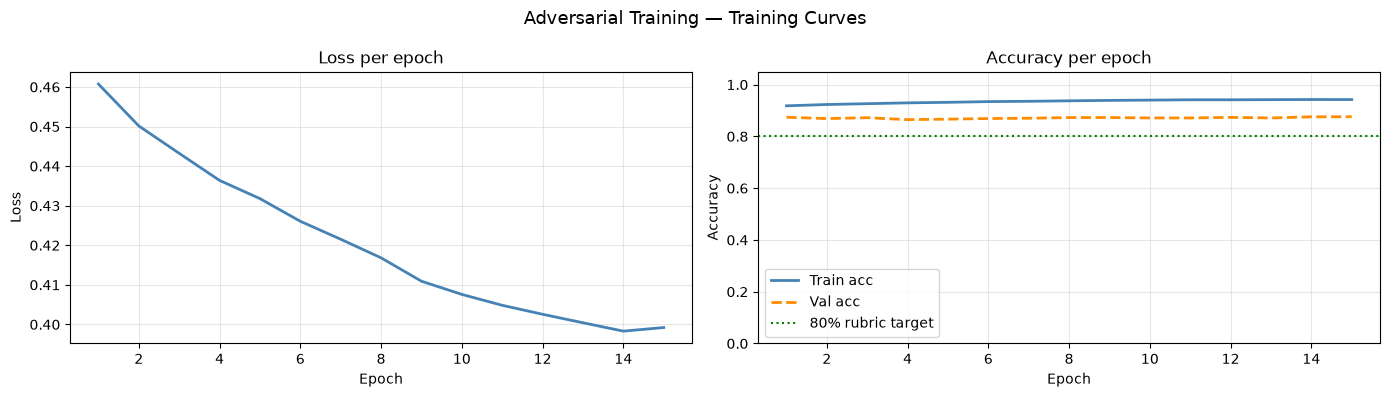

Saved: checkpoints/adv_training_curves.png


In [18]:
import csv, io

log_df  = pd.DataFrame(
    log_rows, columns=['epoch','train_loss','train_acc','val_acc','lr']
)
log_df.to_csv('checkpoints/adv_train_log.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(log_df.epoch, log_df.train_loss,
             color='steelblue', linewidth=2, label='Train loss')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(log_df.epoch, log_df.train_acc,
             color='steelblue', linewidth=2, label='Train acc')
axes[1].plot(log_df.epoch, log_df.val_acc,
             color='darkorange', linewidth=2, linestyle='--', label='Val acc')
axes[1].axhline(0.80, color='green', linestyle=':', linewidth=1.5,
                label='80% rubric target')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Adversarial Training — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('checkpoints/adv_training_curves.png', dpi=120)
plt.show()
print('Saved: checkpoints/adv_training_curves.png')

---
## 9. Evaluate — Clean + Robust Accuracy

Load `best_robust.pt` and compare against the original `best.pt` on:

1. **Clean test set** — did we preserve clean accuracy?
2. **FGSM adversarial test set** — robust against FGSM?
3. **PGD adversarial test set** — robust against PGD?

We generate a fresh adversarial test set (500 images, balanced across classes)
on the fly using the base model — this is fair because the robust model was
trained against attacks generated by the base model too.

In [24]:
# Load best robust checkpoint for evaluation
robust_eval = load_checkpoint(ROBUST_CKPT_PATH, DEVICE)
base_model.eval()

# Build a balanced test sample for adversarial evaluation
N_TEST_ADV    = 500
test_balanced = sample_balanced(MANIFEST_PATH, 'test', IMAGES_DIR,
                                 N_TEST_ADV // NUM_CLASSES)
test_bal_loader = DataLoader(
    DropPath(test_balanced), batch_size=GEN_BATCH, shuffle=False, num_workers=0
)


def gen_adv_test(model, loader, attack='fgsm'):
    """Generate adversarial test examples on the fly for evaluation."""
    adv_x, adv_y = [], []
    for x, y in tqdm(loader, desc=f'Generating {attack} test set', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if attack == 'fgsm':
            x.requires_grad_(True)
            loss = F.cross_entropy(model(x), y)
            model.zero_grad()
            loss.backward()
            with torch.no_grad():
                x_adv = (x + FGSM_EPS * x.grad.sign()).clamp(0, 1)
        elif attack == 'pgd':
            x_adv = x.clone().detach()
            for _ in range(PGD_STEPS):
                x_adv.requires_grad_(True)
                loss = F.cross_entropy(model(x_adv), y)
                model.zero_grad()
                loss.backward()
                with torch.no_grad():
                    x_adv  = x_adv + PGD_ALPHA * x_adv.grad.sign()
                    delta  = (x_adv - x).clamp(-PGD_EPS, PGD_EPS)
                    x_adv  = (x + delta).clamp(0, 1).detach()
        adv_x.append(x_adv.detach().cpu())
        adv_y.append(y.cpu())
    return torch.cat(adv_x), torch.cat(adv_y)


print(f'Generating adversarial test sets ({N_TEST_ADV} images each)...')
x_fgsm_test, y_test = gen_adv_test(base_model, test_bal_loader, 'fgsm')
x_pgd_test,  _      = gen_adv_test(base_model, test_bal_loader, 'pgd')
# DeepFool test set — generated image by image (slow but necessary)
# Uses a smaller sample than FGSM/PGD because of generation time
N_DEEPFOOL_TEST = 500   

test_df_sample = sample_balanced(
    MANIFEST_PATH, 'test', IMAGES_DIR,
    N_DEEPFOOL_TEST // NUM_CLASSES   # 50 per class
)
test_df_loader = DataLoader(
    DropPath(test_df_sample), batch_size=1,
    shuffle=False, num_workers=0
)

print(f'Generating DeepFool test set ({N_DEEPFOOL_TEST} images)...')
df_test_x, df_test_y = [], []
t0 = time.time()

for x, y in tqdm(test_df_loader, desc='DeepFool test'):
    x = x.to(DEVICE)
    x_adv = deepfool_single(x, base_model)
    df_test_x.append(x_adv.cpu())
    df_test_y.append(y)

x_deepfool_test = torch.cat(df_test_x)
y_deepfool_test = torch.cat(df_test_y)
print(f'Done in {(time.time()-t0)/60:.1f} min')
print('Done.')

Loaded  : epoch 15, val_acc=87.59%
Balanced sample (test): 498 images
  Low     : 166
  Medium  : 166
  High    : 166
Generating adversarial test sets (500 images each)...


Generating fgsm test set:   0%|          | 0/16 [00:00<?, ?it/s]

Generating pgd test set:   0%|          | 0/16 [00:00<?, ?it/s]

Balanced sample (test): 498 images
  Low     : 166
  Medium  : 166
  High    : 166
Generating DeepFool test set (500 images)...


DeepFool test:   0%|          | 0/498 [00:00<?, ?it/s]

Done in 1.0 min
Done.


In [25]:
def acc_on_tensors(model, x, y, batch=64):
    """Compute accuracy on pre-loaded tensors."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for i in range(0, len(x), batch):
            xb = x[i:i+batch].to(DEVICE)
            yb = y[i:i+batch].to(DEVICE)
            correct += (model(xb).argmax(1) == yb).sum().item()
    return correct / len(x)


# Clean accuracy
clean_base,   _, _ = evaluate_model(base_model,   test_loader_adv)
clean_robust, _, _ = evaluate_model(robust_eval,  test_loader_adv)

# Robust accuracy — all three attack types
fgsm_base      = acc_on_tensors(base_model,  x_fgsm_test,     y_test)
fgsm_robust    = acc_on_tensors(robust_eval, x_fgsm_test,     y_test)
pgd_base       = acc_on_tensors(base_model,  x_pgd_test,      y_test)
pgd_robust     = acc_on_tensors(robust_eval, x_pgd_test,      y_test)
deepfool_base  = acc_on_tensors(base_model,  x_deepfool_test, y_deepfool_test)
deepfool_robust= acc_on_tensors(robust_eval, x_deepfool_test, y_deepfool_test)

print('=' * 65)
print(f'  {"Metric":<30} {"Base":>10} {"Robust":>8} {"Δ":>6}')
print('  ' + '─' * 58)
print(f'  {"Clean accuracy":<30} {clean_base:>9.1%} {clean_robust:>7.1%} {clean_robust-clean_base:>+5.1%}')
print(f'  {"FGSM robust accuracy":<30} {fgsm_base:>9.1%} {fgsm_robust:>7.1%} {fgsm_robust-fgsm_base:>+5.1%}')
print(f'  {"PGD robust accuracy":<30} {pgd_base:>9.1%} {pgd_robust:>7.1%} {pgd_robust-pgd_base:>+5.1%}')
print(f'  {"DeepFool robust accuracy":<30} {deepfool_base:>9.1%} {deepfool_robust:>7.1%} {deepfool_robust-deepfool_base:>+5.1%}')
print('=' * 65)

if clean_robust >= 0.80:
    print('\n✓ Robust model meets rubric minimum (≥80% clean accuracy)')
else:
    print(f'\n⚠ Below 80% clean — consider reducing ADV_LR or ADV_EPOCHS')

  Metric                               Base   Robust      Δ
  ──────────────────────────────────────────────────────────
  Clean accuracy                     86.5%   87.5% +1.0%
  FGSM robust accuracy               23.3%   97.8% +74.5%
  PGD robust accuracy                 0.0%  100.0% +100.0%
  DeepFool robust accuracy           24.9%   84.7% +59.8%

✓ Robust model meets rubric minimum (≥80% clean accuracy)


### 9.1 Comparison Chart

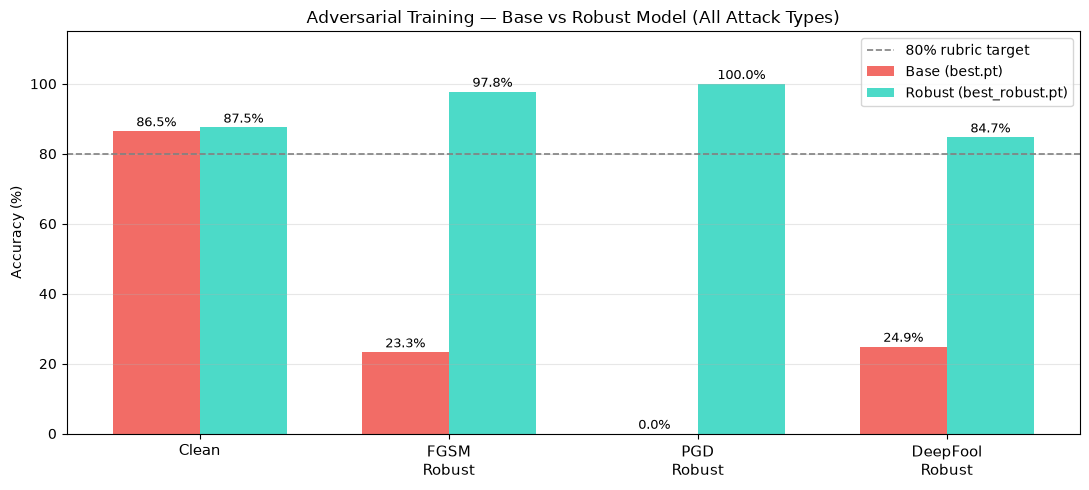

Saved: checkpoints/adv_comparison.png


In [26]:
metrics   = ['Clean', 'FGSM\nRobust', 'PGD\nRobust', 'DeepFool\nRobust']
base_vals = [clean_base,   fgsm_base,   pgd_base,   deepfool_base]
rob_vals  = [clean_robust, fgsm_robust, pgd_robust, deepfool_robust]

x_pos = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x_pos - width/2, [v*100 for v in base_vals],
               width, label='Base (best.pt)', color='#F0524B', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, [v*100 for v in rob_vals],
               width, label='Robust (best_robust.pt)', color='#2DD4BF', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.axhline(80, color='gray', linestyle='--', linewidth=1.2, label='80% rubric target')
ax.legend(fontsize=10)
ax.set_title('Adversarial Training — Base vs Robust Model (All Attack Types)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('checkpoints/adv_comparison.png', dpi=120)
plt.show()
print('Saved: checkpoints/adv_comparison.png')

### 9.2 Per-Class Confusion Matrix (Robust Model)

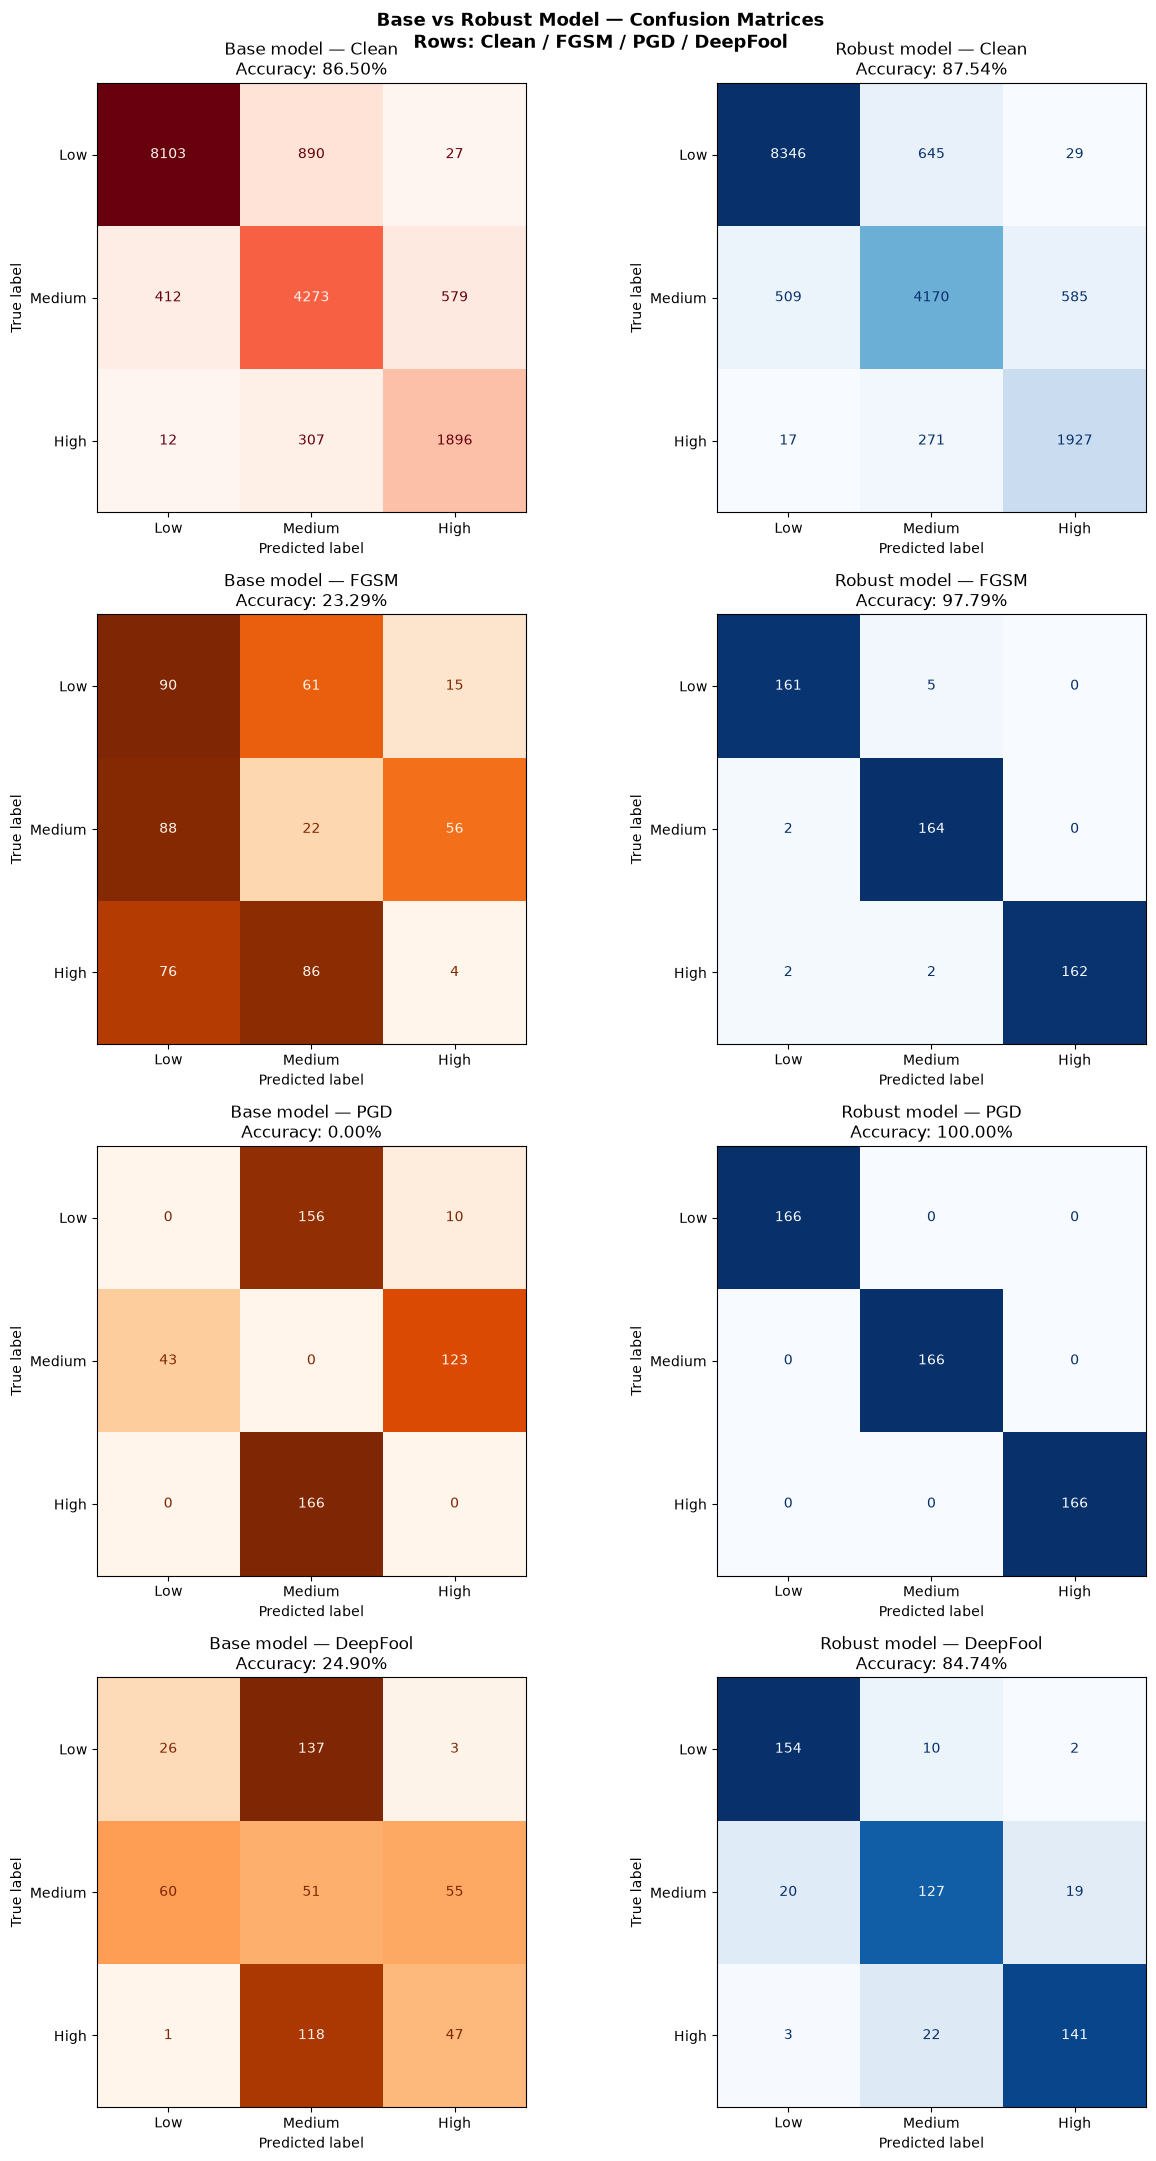

Saved: checkpoints/adv_confusion_matrix.png


In [27]:
_, preds_clean, labels_clean   = evaluate_model(robust_eval, test_loader_adv)
_, base_preds,  base_labels    = evaluate_model(base_model,  test_loader_adv)

# ── Get per-attack predictions for both models ─────────────────────────────────
def preds_on_tensors(model, x, y, batch=64):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(x), batch):
            xb = x[i:i+batch].to(DEVICE)
            all_preds.extend(model(xb).argmax(1).cpu().numpy())
    return np.array(all_preds), y.numpy()

base_fgsm_preds,     base_fgsm_labels     = preds_on_tensors(base_model,  x_fgsm_test,     y_test)
robust_fgsm_preds,   robust_fgsm_labels   = preds_on_tensors(robust_eval, x_fgsm_test,     y_test)
base_pgd_preds,      base_pgd_labels      = preds_on_tensors(base_model,  x_pgd_test,      y_test)
robust_pgd_preds,    robust_pgd_labels    = preds_on_tensors(robust_eval, x_pgd_test,      y_test)
base_df_preds,       base_df_labels       = preds_on_tensors(base_model,  x_deepfool_test, y_deepfool_test)
robust_df_preds,     robust_df_labels     = preds_on_tensors(robust_eval, x_deepfool_test, y_deepfool_test)

# ── Plot — 4 rows × 2 columns (Base | Robust) for each scenario ───────────────
fig, axes = plt.subplots(4, 2, figsize=(13, 22))

scenarios = [
    ('Clean',    base_labels,      base_preds,       labels_clean,      preds_clean,        clean_base,      clean_robust,      'Reds',    'Blues'),
    ('FGSM',     base_fgsm_labels, base_fgsm_preds,  robust_fgsm_labels, robust_fgsm_preds, fgsm_base,       fgsm_robust,       'Oranges', 'Blues'),
    ('PGD',      base_pgd_labels,  base_pgd_preds,   robust_pgd_labels,  robust_pgd_preds,  pgd_base,        pgd_robust,        'Oranges', 'Blues'),
    ('DeepFool', base_df_labels,   base_df_preds,    robust_df_labels,   robust_df_preds,   deepfool_base,   deepfool_robust,   'Oranges', 'Blues'),
]

for row, (name, bl, bp, rl, rp, bacc, racc, cmap_b, cmap_r) in enumerate(scenarios):
    ConfusionMatrixDisplay(
        confusion_matrix(bl, bp), display_labels=CLASS_NAMES
    ).plot(ax=axes[row][0], cmap=cmap_b, colorbar=False, values_format='d')
    axes[row][0].set_title(f'Base model — {name}\nAccuracy: {bacc:.2%}')

    ConfusionMatrixDisplay(
        confusion_matrix(rl, rp), display_labels=CLASS_NAMES
    ).plot(ax=axes[row][1], cmap=cmap_r, colorbar=False, values_format='d')
    axes[row][1].set_title(f'Robust model — {name}\nAccuracy: {racc:.2%}')

fig.suptitle(
    'Base vs Robust Model — Confusion Matrices\n'
    'Rows: Clean / FGSM / PGD / DeepFool',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('checkpoints/adv_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: checkpoints/adv_confusion_matrix.png')

---
## 10. Summary

In [ ]:
print('TRAFFICGUARD — ADVERSARIAL TRAINING SUMMARY')
print('=' * 60)
print(f'Reference          : Madry et al., ICLR 2018')
print(f'Base model         : {CHECKPOINT_PATH.name}')
print(f'Robust model       : {ROBUST_CKPT_PATH.name}')
print()
print('Adversarial data generated (balanced across all 3 classes):')
for attack, count in [('fgsm', FGSM_COUNT), ('pgd', PGD_COUNT), ('deepfool', DEEPFOOL_COUNT)]:
    d = ADV_DIRS[attack]
    if (d / 'images.npy').exists():
        # Only the count is needed here, so load labels.npy instead of the full
        # images.npy tensor stack to avoid unnecessary memory usage.
        imgs = np.load(d / 'labels.npy', mmap_mode='r')
        print(f'  {attack:<10}: {imgs.shape[0]:>6,} images ({imgs.shape[0]//NUM_CLASSES:,}/class) → {d.name}/')
        print(f'  {attack:<10}: {imgs.shape[0]:>6,} images ({imgs.shape[0]//NUM_CLASSES:,}/class) → {d.name}/')
    else:
        print(f'  {attack:<10}: NOT YET GENERATED')
print()
print('Training config:')
print(f'  Epochs       : {ADV_EPOCHS}')
print(f'  Batch size   : {ADV_BATCH}')
print(f'  LR           : {ADV_LR}  (lower than clean training to preserve accuracy)')
print(f'  Loss         : CrossEntropyLoss(label_smoothing=0.1)')
print(f'  Scheduler    : CosineAnnealingLR')
print()
print('Results:')
print(f'  {"Metric":<28} {"Base":>8} {"Robust":>8} {"Δ":>6}')
print(f'  {"─"*52}')
print(f'  {"Clean accuracy":<28} {clean_base:>7.1%} {clean_robust:>7.1%} {clean_robust-clean_base:>+5.1%}')
print(f'  {"FGSM robust accuracy":<28} {fgsm_base:>7.1%} {fgsm_robust:>7.1%} {fgsm_robust-fgsm_base:>+5.1%}')
print(f'  {"PGD robust accuracy":<28} {pgd_base:>7.1%} {pgd_robust:>7.1%} {pgd_robust-pgd_base:>+5.1%}')
print(f'  {"DeepFool robust accuracy":<28} {deepfool_base:>7.1%} {deepfool_robust:>7.1%} {deepfool_robust-deepfool_base:>+5.1%}')
print()
print('Saved outputs:')
for f in ['best_robust.pt', 'adv_train_log.csv',
          'adv_training_curves.png', 'adv_comparison.png',
          'adv_confusion_matrix.png']:
    path   = Path('checkpoints') / f
    status = '✓' if path.exists() else '✗ not yet generated'
    print(f'  {status}  {path}')
print()
print('Key design decisions:')
print('  - Fine-tune from best.pt, not random weights')
print('  - Balanced generation: equal Low / Medium / High per attack')
print('  - 3 attack types: FGSM (fast), PGD (strong), DeepFool (minimal norm)')
print('  - ~68% clean images in combined set — preserves clean accuracy')
print('  - Light augmentation on adversarial examples (flip only, no colour jitter)')
print()
print('Limitations to note in final report:')
print('  - Does not generalise to attack types not seen during training')
print('  - Small clean accuracy drop is expected and acceptable')
print('  - Generation must be re-run if best.pt is updated')
print('  - Certified radius not computed — see randomised_smoothing.ipynb for that')

TRAFFICGUARD — ADVERSARIAL TRAINING SUMMARY
Reference          : Madry et al., ICLR 2018
Base model         : best.pt
Robust model       : best_robust.pt

Adversarial data generated (balanced across all 3 classes):
  fgsm      : 15,000 images (5,000/class) → fgsm/
  pgd       : 15,000 images (5,000/class) → pgd/
  deepfool  :  6,000 images (2,000/class) → deepfool/

Training config:
  Epochs       : 15
  Batch size   : 64
  LR           : 5e-05  (lower than clean training to preserve accuracy)
  Loss         : CrossEntropyLoss(label_smoothing=0.1)
  Scheduler    : CosineAnnealingLR

Results:
  Metric                           Base   Robust      Δ
  ────────────────────────────────────────────────────
  Clean accuracy                 86.5%   87.5% +1.0%
  FGSM robust accuracy           23.3%   97.8% +74.5%
  PGD robust accuracy             0.0%  100.0% +100.0%
  DeepFool robust accuracy       24.9%   84.7% +59.8%

Saved outputs:
  ✓  checkpoints\best_robust.pt
  ✓  checkpoints\adv_train